In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import numpy as np
from PIL import Image
from tempfile import TemporaryDirectory

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)
cudnn.benchmark = True
plt.ion()   # interactive mode

cuda


In [21]:
# Aggregating datasets
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'training': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.39654088, 0.14783458, 0.34960747], [0.31675366, 0.16969393, 0.194807])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.39654088, 0.14783458, 0.34960747], [0.31675366, 0.16969393, 0.194807])
    ]),
}

data_dir = 'image_data' #'image_data3' #'image_data2' #'hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['training', 'test']}
dataloaders = {x: data.DataLoader(image_datasets[x], batch_size=64,
                                             shuffle=True, num_workers=8)
              for x in ['training', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['training', 'test']}
class_names = image_datasets['training'].classes
print(class_names)

['autotuned', 'original']


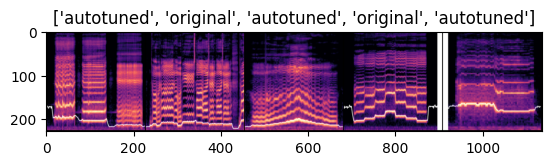

In [22]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['training']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [10]:
from IPython.display import clear_output

epochs = []
losses = {'training' : [], 'test' : []}
accs = {'training' : [], 'test' : []}
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)
            epochs.append(epoch)

            # Each epoch has a training and validation phase
            for phase in ['training', 'test']:
                if phase == 'training':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()
                    with torch.set_grad_enabled(phase == 'training'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'training':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'training':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]
                losses[phase].append(epoch_loss)
                accs[phase].append(epoch_acc.cpu())
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'test' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)
                
            clear_output(wait=True)
            plt.figure(figsize=(10, 12))
            plt.subplot(2, 1, 1)
            plt.plot(epochs, losses['training'], label='Training')
            plt.plot(epochs, losses['test'], label='Validation', color='red')
            plt.title('Model Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True)

            plt.subplot(2, 1, 2)
            plt.plot(epochs, accs['training'], label='Training')
            plt.plot(epochs, accs['test'], label='Validation', color='red')
            plt.title('Model Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.grid(True)
            plt.show()
            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')
        plt.savefig(f"training_results_{time.time()}.png", dpi=300, bbox_inches='tight', pad_inches = 0)
        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [11]:
model = models.resnet50(weights='DEFAULT') # 150 layers
for param in model.parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if "layer2" in name or "layer3" in name or "layer4" in name:
        print(name)
        param.requires_grad = True
model.avgpool.requires_grad_(True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, verbose=True)

#lr_schedule = optim.lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=5)

#@torch.compile(fullgraph=False)
#def compiled_step():
#    optimizer.step()

#@torch.compile(fullgraph=False)
#def compiled_loss(outputs, labels):
#    return criterion(outputs, labels)

#inputs, labels = next(iter(dataloaders['training']))
#inputs = inputs.to(device)
#labels = labels.to(device)
# Sanity checks
#outputs = model(inputs)
#loss = criterion(outputs, labels)
#print(loss.item())

layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.conv3.weight
layer2.0.bn3.weight
layer2.0.bn3.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer2.1.conv3.weight
layer2.1.bn3.weight
layer2.1.bn3.bias
layer2.2.conv1.weight
layer2.2.bn1.weight
layer2.2.bn1.bias
layer2.2.conv2.weight
layer2.2.bn2.weight
layer2.2.bn2.bias
layer2.2.conv3.weight
layer2.2.bn3.weight
layer2.2.bn3.bias
layer2.3.conv1.weight
layer2.3.bn1.weight
layer2.3.bn1.bias
layer2.3.conv2.weight
layer2.3.bn2.weight
layer2.3.bn2.bias
layer2.3.conv3.weight
layer2.3.bn3.weight
layer2.3.bn3.bias
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.conv3.weight
layer3.0.bn3.weight
layer3.0.bn3.bias
layer3.0.downsa

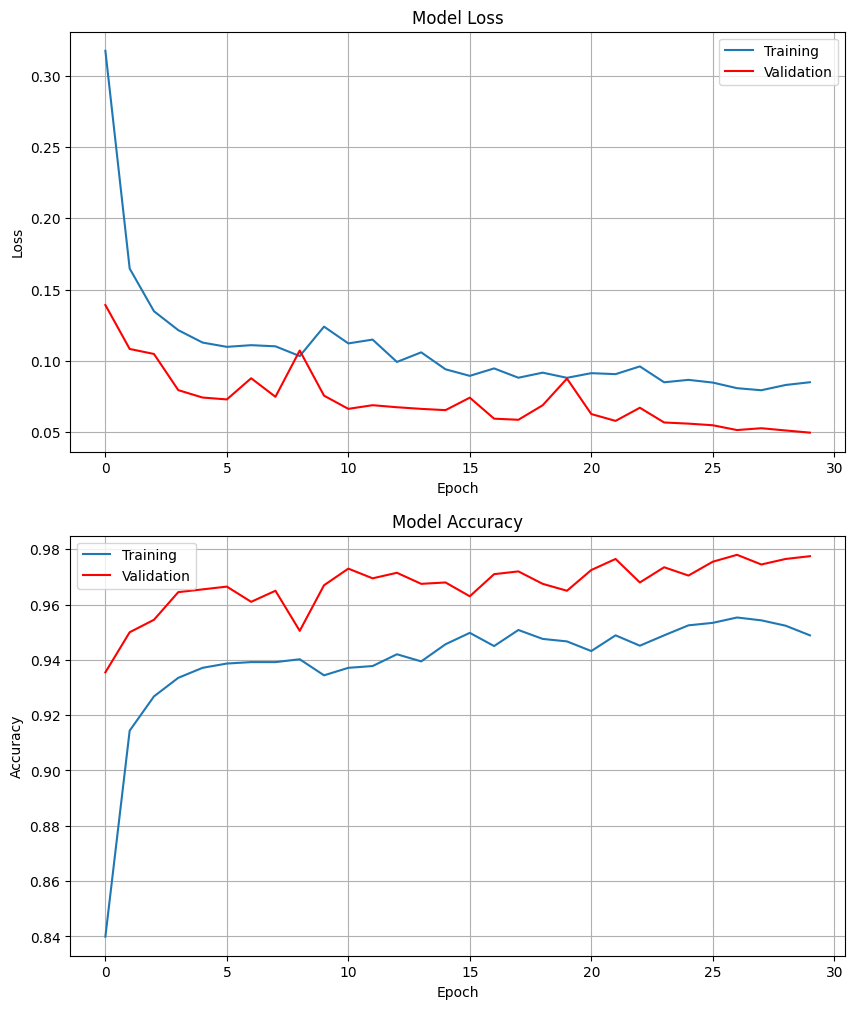


Training complete in 40m 15s
Best val Acc: 0.978000


<Figure size 640x480 with 0 Axes>

In [12]:
total_epochs = 0
model_conv = train_model(model, criterion, optimizer, scheduler, num_epochs=30)

In [30]:
# Testing the model

# Define the same transformations used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize image
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize([0.39654088, 0.14783458, 0.34960747], [0.31675366, 0.16969393, 0.194807])
])

count = 0
autotuned_segs = 0
for root, dirs, files in os.walk('Boom_Boom_Pow/plots'):
    for file in files:
        # Load and preprocess the image
        #print(root, file)
        image = Image.open(os.path.join(root, file)).convert("RGB")  # Open image
        image = transform(image).unsqueeze(0).to(device)  # Add batch dimension
        with torch.no_grad():
            output = model(image)  # Get model predictions
            predicted_class = torch.argmax(output, dim=1).item()  # Get class index
            print("Predicted Class:", predicted_class)
            if predicted_class == 0:
                autotuned_segs += 1
        count += 1
print((autotuned_segs / count) * 100, "percent of segments are autotuned")

Predicted Class: 0
Predicted Class: 0
Predicted Class: 1
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
95.45454545454545 percent of segments are autotuned


In [31]:
count = 0
autotuned_segs = 0
for root, dirs, files in os.walk('Viva_La_Vida_Coldplay/plots'):
    for file in files:
        # Load and preprocess the image
        #print(root, file)
        image = Image.open(os.path.join(root, file)).convert("RGB")  # Open image
        image = transform(image).unsqueeze(0).to(device)  # Add batch dimension
        with torch.no_grad():
            output = model(image)  # Get model predictions
            predicted_class = torch.argmax(output, dim=1).item()  # Get class index
            print("Predicted Class:", predicted_class)
            if predicted_class == 0:
                autotuned_segs += 1
        count += 1
print((autotuned_segs / count) * 100, "percent of segments are autotuned")

Predicted Class: 0
Predicted Class: 1
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 1
Predicted Class: 1
Predicted Class: 0
Predicted Class: 0
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
Predicted Class: 0
70.0 percent of segments are autotuned


In [32]:
count = 0
autotuned_segs = 0
for root, dirs, files in os.walk('Bouquet_Ichiko_Aoba/plots'):
    for file in files:
        # Load and preprocess the image
        #print(root, file)
        image = Image.open(os.path.join(root, file)).convert("RGB")  # Open image
        image = transform(image).unsqueeze(0).to(device)  # Add batch dimension
        with torch.no_grad():
            output = model(image)  # Get model predictions
            predicted_class = torch.argmax(output, dim=1).item()  # Get class index
            print("Predicted Class:", predicted_class)
            if predicted_class == 0:
                autotuned_segs += 1
        count += 1
print((autotuned_segs / count) * 100, "percent of segments are autotuned")

Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
Predicted Class: 1
0.0 percent of segments are autotuned
